<a href="https://colab.research.google.com/github/ahmedinB/Computer-Vision-Fundamentals/blob/main/FastRCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install selectivesearch torch_snippets kagglehub

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 100.2 MB/s eta 0:00:00
  Created wheel for selectivesearch: filen

In [ ]:
from torch_snippets import logger, show
import selectivesearch
from torchvision import transforms, models, datasets
from torchvision.ops import nms
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [ ]:
import kagglehub
trucks_and_buses = kagglehub.dataset_download('sixhky/open-images-bus-trucks')
print('Trucks and buses dataset download complete at :' , trucks_and_buses)

Using Colab cache for faster access to the 'open-images-bus-trucks' dataset.
Trucks and buses dataset download complete at : /kaggle/input/open-images-bus-trucks


In [ ]:
def extract_candidates(img):
  img_lbl, regions = selectivesearch.selective_search(img, scale=500, min_size=100)
  img_area = np.prod(img.shape[:2])
  candidates = []

  for r in regions:
    if r['rect'] in candidates: continue
    if r['size'] < (0.05* img_area): continue
    if r['size'] > (1*img_area): continue
    x, y, w, h = r['rect']
    candidates.append(list(r['rect']))

  return candidates


In [ ]:
def extract_iou(boxA, boxB, epsilon=1e-5):

  x1 = max(boxA[0], boxB[0])
  y1 = max(boxA[1], boxB[1])
  x2 = min(boxA[2], boxB[2])
  y2 = min(boxA[3], boxB[3])

  width = (x2 - x1)
  height = (y2 - y1)

  if (width < 0) or (height < 0):
    return 0

  area_overlap = width*height

  area_a = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
  area_b = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

  area_combined = area_a + area_b - area_overlap
  iou = area_overlap / (area_combined + epsilon)
  return iou

In [ ]:
IMAGE_ROOT = trucks_and_buses + '/images/images'
DF_RAW = pd.read_csv(trucks_and_buses + '/df.csv')
DF_RAW.head()

,ImageID,Source,LabelName,Confidence,XMin,XMax,YMin,YMax,IsOccluded,IsTruncated,...,IsDepiction,IsInside,XClick1X,XClick2X,XClick3X,XClick4X,XClick1Y,XClick2Y,XClick3Y,XClick4Y
0,0000599864fd15b3,xclick,Bus,1,0.343750,0.908750,0.156162,0.650047,1,0,...,0,0,0.421875,0.343750,0.795000,0.908750,0.156162,0.512700,0.650047,0.457197
1,00006bdb1eb5cd74,xclick,Truck,1,0.276667,0.697500,0.141604,0.437343,1,0,...,0,0,0.299167,0.276667,0.697500,0.659167,0.141604,0.241855,0.352130,0.437343
2,00006bdb1eb5cd74,xclick,Truck,1,0.702500,0.999167,0.204261,0.409774,1,1,...,0,0,0.849167,0.702500,0.906667,0.999167,0.204261,0.398496,0.409774,0.295739
3,00010bf498b64bab,xclick,Bus,1,0.156250,0.371250,0.269188,0.705228,0,0,...,0,0,0.274375,0.371250,0.311875,0.156250,0.269188,0.493882,0.705228,0.521691
4,00013f14dd4e168f,xclick,Bus,1,0.287500,0.999375,0.194184,0.999062,0,1,...,0,0,0.920000,0.999375,0.648750,0.287500,0.194184,0.303940,0.999062,0.523452


In [ ]:
class OpenImages(Dataset):
  def __init__(self, df, image_folder=IMAGE_ROOT):
    self.root = image_folder
    self.df = df
    self.unique_images = df['ImageID'].unique()

  def __len__(self): return len(self.unique_images)
  def __getitem__(self, ix):
    image_id = self.unique_images[ix]
    image_path = f'{self.root}/{image_id}.jpg'
    image = cv2.imread(image_path, 1)[..., ::-1]
    h, w, _ = image.shape
    df = self.df.copy()

    df = df[df['ImageID'] == image_id]
    boxes = df['XMin,YMin,XMax,YMax'.split(',')].values
    boxes = (boxes * np.array([w,h,w,h])).astype(np.uint16).tolist()

    classes = df['LabelName'].values.tolist()
    return image, boxes, classes, image_path


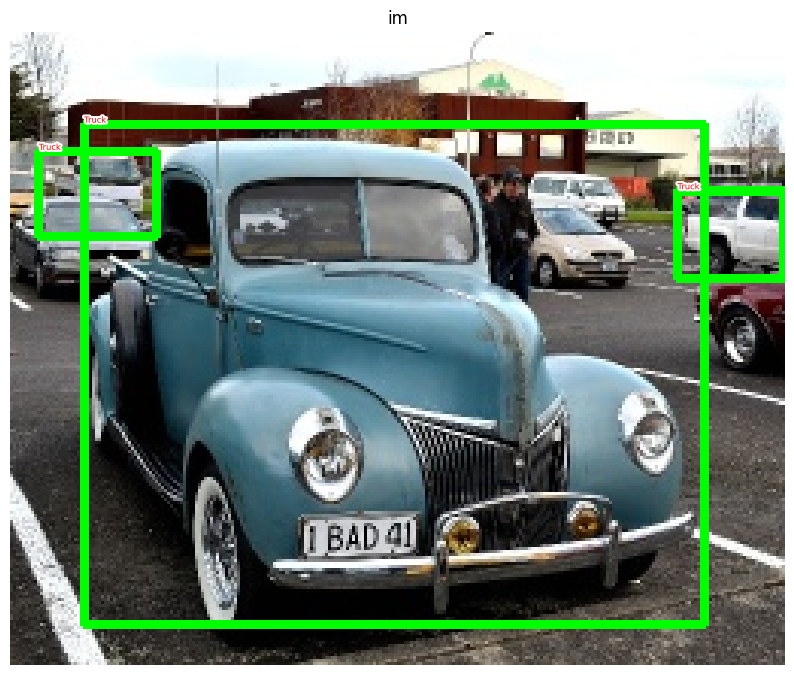

[[9, 39, 48, 67], [24, 30, 229, 195], [220, 52, 255, 81]]


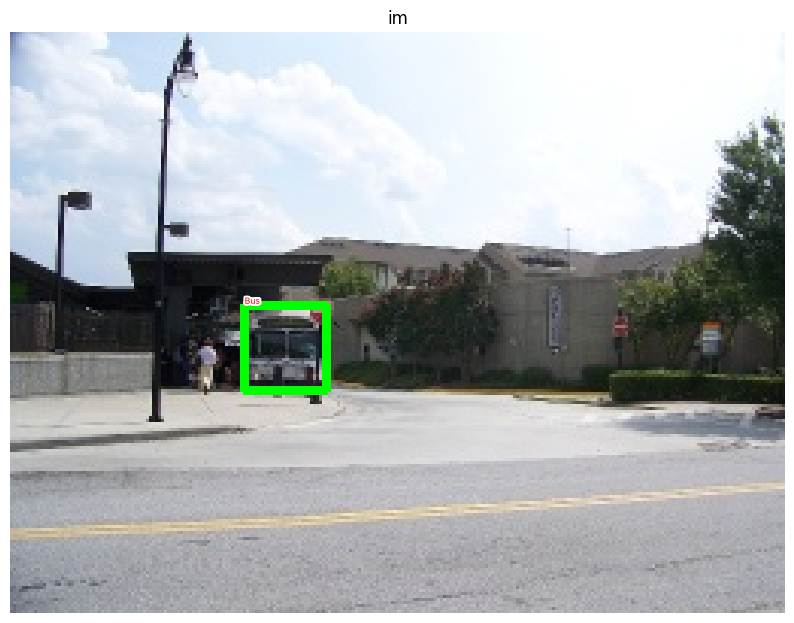

[[77, 90, 104, 118]]


In [ ]:
  ds = OpenImages(df=DF_RAW)
  im, bbs, clss, _ = ds[6]
  show(im, bbs=bbs, texts=clss, sz =10)
  print(bbs)

  im, bbs, clss, _ = ds[15]
  show(im, bbs=bbs, texts = clss, sz = 10)
  print(bbs)

In [ ]:
FPATHS, GTBBS, CLSS, DELTAS, ROIS, IOUS = [], [], [], [], [], []
N = 500

for ix, (im, bbs, labels, fpath) in enumerate(ds):
  if (ix==N):
    break

  H, W, _ = im.shape
  candidates = extract_candidates(im)

  candidates = np.array([(x, y, x+w, y+h) for x, y, w, h in candidates])

  ious, rois, clss, deltas = [], [], [], []

  ious = np.array([[extract_iou(candidate, _bb_) for candidate in candidates] for _bb_ in bbs]).T

  for jx, candidate in enumerate(candidates):
    cx, cy, cX, cY = candidate

    candidate_ious = ious[jx]

    best_ious_at = np.argmax(candidate_ious)

    best_iou = candidate_ious[best_ious_at]

    best_bb = _x, _y, _X, _Y = bbs[best_ious_at]

    if best_iou > 0.3 : clss.append(labels[best_ious_at])
    else: clss.append('background')

    delta = np.array([_x-cx, _y-cy, _X-cX, _Y-cY]) / np.array([W,H,W,H])

    deltas.append(delta)
    rois.append(candidate/np.array([W,H,W,H]))

  FPATHS.append(fpath)
  IOUS.append(ious)
  ROIS.append(rois)
  CLSS.append(clss)
  DELTAS.append(deltas)
  GTBBS.append(bbs)

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3

In [ ]:
import os
FPATHS = [f'{IMAGE_ROOT}/{os.path.splitext(os.path.basename(f))[0]}.jpg' for f in FPATHS]

FPATHS, GTBBS, CLSS, DELTAS, ROIS = [item for item in [FPATHS, GTBBS, CLSS, DELTAS, ROIS]]

In [ ]:
from itertools import chain

def flatten(list_of_lists):
  return list(chain.from_iterable(list_of_lists))

targets = pd.DataFrame(flatten(CLSS), columns=['label'])

label2target = {l : t for t, l in enumerate(targets['label'].unique())}
target2label = {t : l for l, t in label2target.items()}

background_class = label2target['background']

print("The label to target values dictionary formed is: ", label2target)

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def preprocess_image(img):
  img = torch.tensor(img).permute(2,0,1)
  img = normalize(img)
  return img.to(device).float()

def decode(_y):
  _, preds = _y.max(-1)
  return preds

The label to target values dictionary formed is:  {'background': 0, 'Bus': 1, 'Truck': 2}


In [ ]:
# @title
class FastRCNNDataset(Dataset):
  def __init__(self, fpaths, rois, labels, deltas, gtbbs):
    self.fpaths = fpaths
    self.rois = rois
    self.labels = labels
    self.deltas = deltas
    self.gtbbs = gtbbs

  def __len__(self): return len(self.fpaths)

  def __getitem__(self, ix):
    fpath = str(self.fpaths[ix])
    image = cv2.imread(fpath, 1)[...,::-1]
    H, W, _ = image.shape
    sh = np.array([W, H, W, H])
    gtbbs = self.gtbbs[ix]
    rois = self.rois[ix]

    bbs = (np.array(rois)*sh).astype(np.uint16)
    labels = self.labels[ix]
    deltas = self.deltas[ix]

    return image, bbs, labels, deltas, gtbbs, fpath

  def collate_fn(self, batch):
    images, rois_list, labels, deltas = [], [], [], []

    for ix in range(len(batch)):
      image, image_bbs, image_labels, image_deltas, image_gt_bbs, image_fpath = batch[ix]

      # Get original dimensions before resizing
      orig_H, orig_W = image.shape[:2]

      # Preprocess the full image (resize to fixed size for batching)
      image_resized = cv2.resize(image, (224, 224))
      image_tensor = preprocess_image(image_resized / 255.)
      images.append(image_tensor[None])

      # Scale ROIs from original pixel coords to resized 224x224 coords
      scale_x = 224.0 / orig_W
      scale_y = 224.0 / orig_H
      scaled_bbs = image_bbs.astype(np.float32).copy()
      scaled_bbs[:, [0, 2]] *= scale_x
      scaled_bbs[:, [1, 3]] *= scale_y
      rois_list.append(torch.tensor(scaled_bbs).float().to(device))

      labels.extend([label2target[c] for c in image_labels])
      deltas.extend(image_deltas)

    images = torch.cat(images).to(device)
    labels = torch.tensor(labels).long().to(device)
    deltas = torch.tensor(np.array(deltas)).float().to(device)
    return images, rois_list, labels, deltas

In [ ]:
# @title
from torchvision.ops import RoIPool

class FastRCNN(nn.Module):
  def __init__(self):
    super().__init__()
    # Use VGG16 convolutional features only (shared feature extractor)
    vgg = models.vgg16(pretrained=True)
    self.backbone = vgg.features  # Conv layers only
    # for param in self.backbone.parameters():
    #   param.requires_grad = False
    self.backbone.eval()

    # RoI Pooling layer: output 7x7 feature maps per RoI
    self.roi_pool = RoIPool(output_size=(7, 7), spatial_scale=1/16.0)

    # Classification and regression heads (operate on pooled features)
    roi_feature_dim = 512 * 7 * 7  # 512 channels x 7x7 spatial
    self.head = nn.Sequential(
        nn.Linear(roi_feature_dim, 4096),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(4096, 4096),
        nn.ReLU(),
        nn.Dropout(0.5),
    )
    self.cls_score = nn.Linear(4096, len(label2target))
    self.bbox = nn.Sequential(
        nn.Linear(4096, 4),
        nn.Tanh(),
    )
    self.cel = nn.CrossEntropyLoss()
    self.sl1 = nn.L1Loss()

  def forward(self, image, rois):
    # image: (B, C, H, W) - batch of full images
    # rois: list of tensors, each (N_i, 4) in [x1, y1, x2, y2] pixel coords
    feat = self.backbone(image)  # Shared feature map

    # Format rois for RoIPool: (K, 5) where each row is [batch_idx, x1, y1, x2, y2]
    roi_list = []
    for i, roi in enumerate(rois):
      batch_idx = torch.full((roi.shape[0], 1), i, dtype=torch.float32, device=roi.device)
      roi_list.append(torch.cat([batch_idx, roi], dim=1))
    rois_tensor = torch.cat(roi_list, dim=0)

    pooled = self.roi_pool(feat, rois_tensor)  # (K, 512, 7, 7)
    pooled = pooled.view(pooled.size(0), -1)   # (K, 512*7*7)

    features = self.head(pooled)
    cls_score = self.cls_score(features)
    bbox = self.bbox(features)
    return cls_score, bbox

  def calc_loss(self, probs, _deltas, labels, deltas):
    detection_loss = self.cel(probs, labels)
    ixs, = torch.where(labels != background_class)
    _deltas = _deltas[ixs]
    deltas = deltas[ixs]
    self.lmb = 10.0
    if len(ixs) > 0:
      regression_loss = self.sl1(_deltas, deltas)
      return detection_loss + self.lmb * regression_loss, detection_loss.detach(), regression_loss.detach()
    else:
      regression_loss = 0
      return detection_loss + self.lmb * regression_loss, detection_loss.detach(), regression_loss

In [ ]:
from sklearn.model_selection import train_test_split

# Number of unique images used
n_images = len(FPATHS)

# Split indices into train and test
all_indices = list(range(n_images))
train_idx, test_idx = train_test_split(all_indices, test_size=0.2, random_state=42)

# Helper to subset lists by indices
def subset(data, indices):
  return [data[i] for i in indices]

# Create train and test datasets
train_ds = FastRCNNDataset(
    fpaths=subset(FPATHS, train_idx),
    rois=subset(ROIS, train_idx),
    labels=subset(CLSS, train_idx),
    deltas=subset(DELTAS, train_idx),
    gtbbs=subset(GTBBS, train_idx),
)

test_ds = FastRCNNDataset(
    fpaths=subset(FPATHS, test_idx),
    rois=subset(ROIS, test_idx),
    labels=subset(CLSS, test_idx),
    deltas=subset(DELTAS, test_idx),
    gtbbs=subset(GTBBS, test_idx),
)

# DataLoaders - batch_size=2 since we pass full images
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True,
                          collate_fn=train_ds.collate_fn, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=False,
                         collate_fn=test_ds.collate_fn, drop_last=True)

# Initialize model
fastrcnn = FastRCNN().to(device)

# Optimizer - only train the head, cls_score, and bbox layers (backbone is frozen)
optimizer = SGD(
    [p for p in fastrcnn.parameters() if p.requires_grad],
    lr=1e-3, momentum=0.9, weight_decay=0.0005
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print(f"Train images: {len(train_ds)}, Test images: {len(test_ds)}")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 113MB/s]


Train images: 400, Test images: 100
Train batches: 200, Test batches: 50


Epoch 1/10 | Train Loss: 1.5440 | Test Loss: 1.6502 | Test Acc: 0.6670
Epoch 2/10 | Train Loss: 1.4999 | Test Loss: 1.6397 | Test Acc: 0.6738
Epoch 3/10 | Train Loss: 1.4717 | Test Loss: 1.6251 | Test Acc: 0.6781
Epoch 4/10 | Train Loss: 1.4540 | Test Loss: 1.6206 | Test Acc: 0.6857
Epoch 5/10 | Train Loss: 1.4364 | Test Loss: 1.6077 | Test Acc: 0.6880
Epoch 6/10 | Train Loss: 1.4075 | Test Loss: 1.6051 | Test Acc: 0.6878
Epoch 7/10 | Train Loss: 1.3988 | Test Loss: 1.6046 | Test Acc: 0.6874
Epoch 8/10 | Train Loss: 1.3977 | Test Loss: 1.6018 | Test Acc: 0.6862
Epoch 9/10 | Train Loss: 1.4047 | Test Loss: 1.6018 | Test Acc: 0.6878
Epoch 10/10 | Train Loss: 1.4017 | Test Loss: 1.6011 | Test Acc: 0.6879


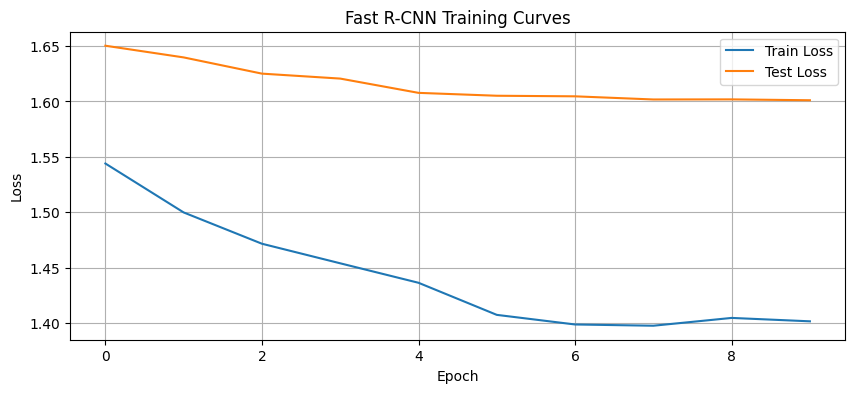

In [ ]:
# Training Loop
n_epochs = 10

# Track losses for plotting
train_loss_history = []
test_loss_history = []

def train_batch(model, data, optimizer):
  model.train()
  # Freeze backbone even in train mode
  model.backbone.eval()
  optimizer.zero_grad()

  images, rois_list, labels, deltas = data
  cls_scores, bbox_preds = model(images, rois_list)

  loss, cls_loss, reg_loss = model.calc_loss(cls_scores, bbox_preds, labels, deltas)
  loss.backward()
  optimizer.step()
  return loss.item(), cls_loss.item(), reg_loss if isinstance(reg_loss, int) else reg_loss.item()

@torch.no_grad()
def validate_batch(model, data):
  model.eval()
  images, rois_list, labels, deltas = data
  cls_scores, bbox_preds = model(images, rois_list)
  loss, cls_loss, reg_loss = model.calc_loss(cls_scores, bbox_preds, labels, deltas)

  # Calculate accuracy
  preds = decode(cls_scores)
  acc = (preds == labels).float().mean().item()
  return loss.item(), cls_loss.item(), reg_loss if isinstance(reg_loss, int) else reg_loss.item(), acc

for epoch in range(n_epochs):
  # Training
  epoch_train_loss = []
  for batch_data in train_loader:
    loss, cls_loss, reg_loss = train_batch(fastrcnn, batch_data, optimizer)
    epoch_train_loss.append(loss)

  avg_train_loss = np.mean(epoch_train_loss)
  train_loss_history.append(avg_train_loss)

  # Validation
  epoch_test_loss = []
  epoch_test_acc = []
  for batch_data in test_loader:
    loss, cls_loss, reg_loss, acc = validate_batch(fastrcnn, batch_data)
    epoch_test_loss.append(loss)
    epoch_test_acc.append(acc)

  avg_test_loss = np.mean(epoch_test_loss)
  avg_test_acc = np.mean(epoch_test_acc)
  test_loss_history.append(avg_test_loss)

  scheduler.step()

  print(f"Epoch {epoch+1}/{n_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Test Loss: {avg_test_loss:.4f} | "
        f"Test Acc: {avg_test_acc:.4f}")

# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(test_loss_history, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fast R-CNN Training Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
@torch.no_grad()
def predict_image(model, image_path, conf_threshold=0.5, nms_threshold=0.3):
  """
  Run Fast R-CNN inference on a single image:
  1. Generate region proposals with Selective Search
  2. Pass full image through shared backbone
  3. RoI pool each proposal
  4. Predict class + bbox offset for each proposal
  5. Apply NMS to remove duplicate detections
  """
  model.eval()

  # Load image
  image = cv2.imread(image_path, 1)[..., ::-1]
  orig_H, orig_W = image.shape[:2]

  # Generate region proposals
  candidates = extract_candidates(image)
  candidates = np.array([(x, y, x+w, y+h) for x, y, w, h in candidates])

  if len(candidates) == 0:
    print("No candidates found")
    return image, [], [], []

  # Resize image for the model
  image_resized = cv2.resize(image, (224, 224))
  img_tensor = preprocess_image(image_resized / 255.)[None].to(device)

  # Scale candidates to 224x224 space
  scale_x = 224.0 / orig_W
  scale_y = 224.0 / orig_H
  scaled_candidates = candidates.astype(np.float32).copy()
  scaled_candidates[:, [0, 2]] *= scale_x
  scaled_candidates[:, [1, 3]] *= scale_y
  rois_tensor = torch.tensor(scaled_candidates).float().to(device)

  # Forward pass
  cls_scores, bbox_offsets = model(img_tensor, [rois_tensor])

  # Get class probabilities
  probs = torch.softmax(cls_scores, dim=1)
  class_preds = probs.argmax(dim=1)
  class_confs = probs.max(dim=1).values

  # Filter out background predictions and low-confidence
  keep_mask = (class_preds != background_class) & (class_confs > conf_threshold)
  keep_idx = torch.where(keep_mask)[0]

  if len(keep_idx) == 0:
    print("No objects detected above confidence threshold")
    return image, [], [], []

  # Get kept predictions (in original image coordinates)
  kept_boxes = candidates[keep_idx.cpu().numpy()]
  kept_offsets = bbox_offsets[keep_idx].cpu().numpy()
  kept_classes = class_preds[keep_idx].cpu().numpy()
  kept_confs = class_confs[keep_idx].cpu().numpy()

  # Apply bbox offsets to refine boxes
  refined_boxes = kept_boxes.copy().astype(np.float32)
  refined_boxes[:, 0] += kept_offsets[:, 0] * orig_W
  refined_boxes[:, 1] += kept_offsets[:, 1] * orig_H
  refined_boxes[:, 2] += kept_offsets[:, 2] * orig_W
  refined_boxes[:, 3] += kept_offsets[:, 3] * orig_H
  refined_boxes = refined_boxes.astype(np.int32)

  # Clip to image boundaries
  refined_boxes[:, [0, 2]] = np.clip(refined_boxes[:, [0, 2]], 0, orig_W)
  refined_boxes[:, [1, 3]] = np.clip(refined_boxes[:, [1, 3]], 0, orig_H)

  # Apply NMS per class
  final_boxes, final_labels, final_scores = [], [], []
  for cls_id in np.unique(kept_classes):
    cls_mask = kept_classes == cls_id
    cls_boxes = torch.tensor(refined_boxes[cls_mask]).float()
    cls_scores_nms = torch.tensor(kept_confs[cls_mask]).float()
    nms_keep = nms(cls_boxes, cls_scores_nms, nms_threshold)
    # nms_keep = nms(cls_boxes, cls_scores_nms, nms_threshold)

    final_boxes.extend(cls_boxes[nms_keep].int().numpy().tolist())
    final_labels.extend([target2label[cls_id]] * len(nms_keep))
    final_scores.extend(cls_scores_nms[nms_keep].numpy().tolist())

  return image, final_boxes, final_labels, final_scores

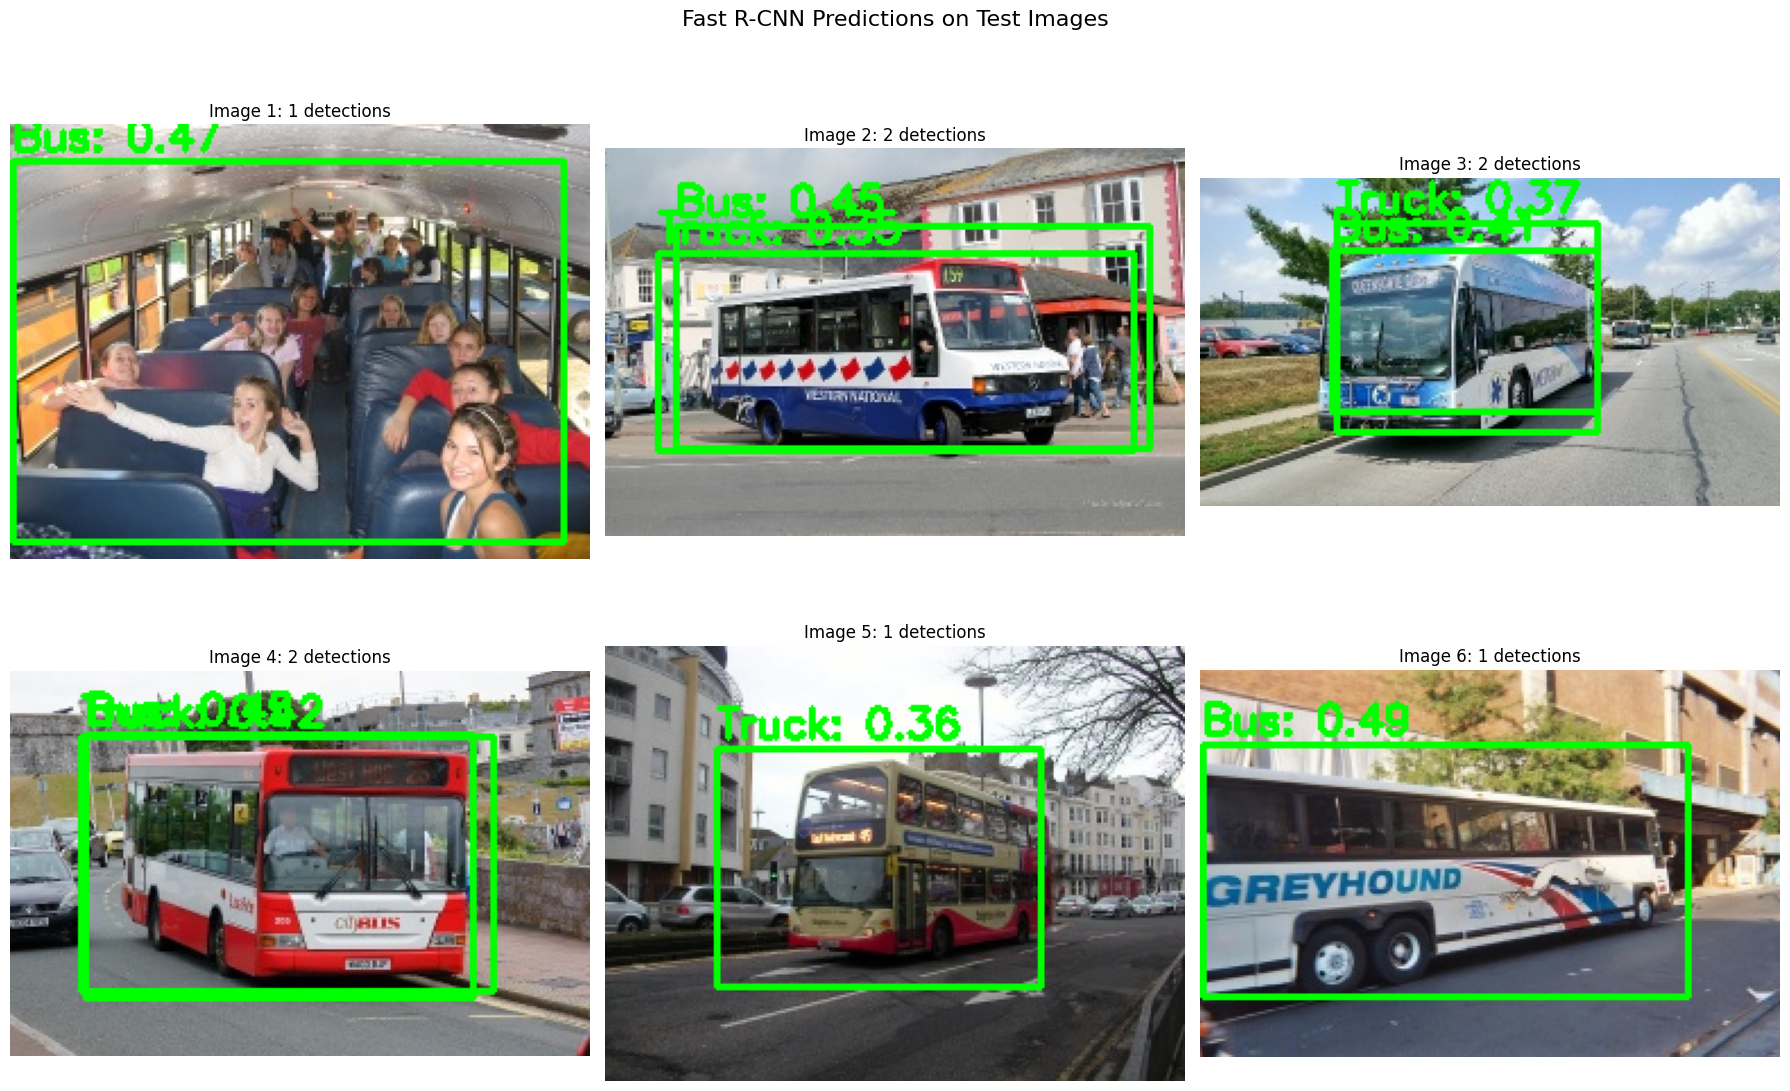


--- Detailed Results for first test image ---
No objects detected above confidence threshold


In [ ]:
test_fpaths = subset(FPATHS, test_idx)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
  if i >= len(test_fpaths):
    ax.axis('off')
    continue

  fpath = test_fpaths[i]
  image, boxes, labels, scores = predict_image(fastrcnn, fpath,
                                                conf_threshold=0.3,
                                                nms_threshold=0.3)

  # Draw bounding boxes on image
  img_draw = image.copy()
  for box, label, score in zip(boxes, labels, scores):
    x1, y1, x2, y2 = box
    cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0, 255, 0), 2)
    text = f"{label}: {score:.2f}"
    cv2.putText(img_draw, text, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  ax.imshow(img_draw)
  ax.set_title(f"Image {i+1}: {len(boxes)} detections")
  ax.axis('off')

plt.suptitle("Fast R-CNN Predictions on Test Images", fontsize=16)
plt.tight_layout()
plt.show()

# Print detailed results for the first test image
print("\n--- Detailed Results for first test image ---")
fpath = test_fpaths[0]
image, boxes, labels, scores = predict_image(fastrcnn, fpath)
for box, label, score in zip(boxes, labels, scores):
  print(f"  Class: {label:12s} | Confidence: {score:.4f} | Box: {box}")